### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [78]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
import pandas as pd
customers_df = pd.read_csv('marketing_campaign.csv', sep="\t")
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [18]:
customers_df.Education.value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [24]:
customers_df.Marital_Status.value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
customers_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

В цьому датасеті немає пропущених значень, але для заповнення даних в задачах кластерізації можно використовувати такий підхід
- Якщо мало NaN → видалити рядки.
- Якщо NaN небагато, але в важливих ознаках → медіана/мода.
- Якщо даних багато і потрібні більш точні кластери → спробувати KNNImputer.
- Якщо пропуски мають зміст → додати прапорець is_missing.

Потім таки знайшлись в колонці Income

In [50]:
customers_df.Income.describe()

count      2212.000000
mean      52232.510850
std       25187.455359
min        1730.000000
25%       35233.500000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

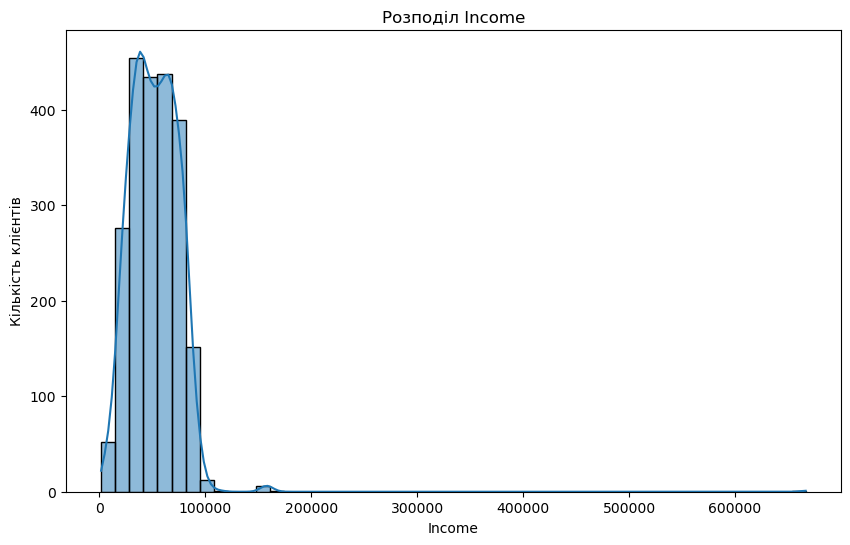

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers_df["Income_numeric"] = pd.to_numeric(customers_df["Income"], errors="coerce")

plt.figure(figsize=(10,6))
sns.histplot(customers_df["Income_numeric"], bins=50, kde=True)
plt.title("Розподіл Income")
plt.xlabel("Income")
plt.ylabel("Кількість клієнтів")
plt.show()

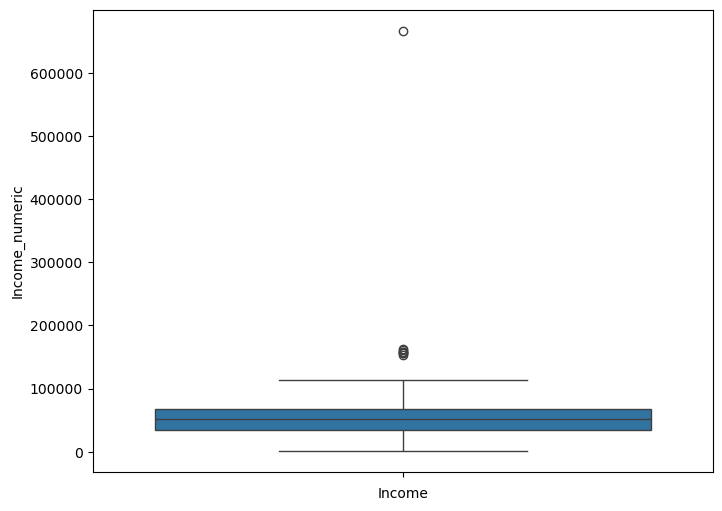

In [66]:
plt.figure(figsize=(8,6))
sns.boxplot(y=customers_df["Income_numeric"])
plt.xlabel("Income")
plt.show()

In [80]:
median_income = customers_df["Income"].median()
customers_df["Income"].fillna(median_income, inplace=True)

q_low, q_high = customers_df["Income"].quantile([0.01, 0.99])
customers_df["Income"] = customers_df["Income"].clip(lower=q_low, upper=q_high)

Я заповнила відсутні значення медіаною, тому що ми маємо викид. Який до того ж виглядає нереалістично, тому для алгоритмів чутливих до викидів його бажано забрати.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [9]:
from sklearn.preprocessing import OrdinalEncoder

customers_df["Dt_Customer"] = pd.to_datetime(customers_df["Dt_Customer"],  format="%d-%m-%Y")

customers_df["year"] = customers_df["Dt_Customer"].dt.year
customers_df["month"] = customers_df["Dt_Customer"].dt.month
customers_df["day"] = customers_df["Dt_Customer"].dt.day
customers_df["day_of_week"] = customers_df["Dt_Customer"].dt.dayofweek  

education_order = [["Basic", "2n Cycle", "Graduation", "Master", "PhD"]]
encoder = OrdinalEncoder(categories=education_order)
customers_df["Education_encoded"] = encoder.fit_transform(customers_df[["Education"]])

customers_df["Marital_Status"] = customers_df["Marital_Status"].replace({"Alone": "Single"})
customers_df = customers_df[~customers_df["Marital_Status"].isin(["YOLO", "Absurd"])]
df_encoded = pd.get_dummies(customers_df, columns=["Marital_Status"], prefix="Marital")
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2236 non-null   int64         
 1   Year_Birth           2236 non-null   int64         
 2   Education            2236 non-null   object        
 3   Marital_Status       2236 non-null   object        
 4   Income               2236 non-null   float64       
 5   Kidhome              2236 non-null   int64         
 6   Teenhome             2236 non-null   int64         
 7   Dt_Customer          2236 non-null   datetime64[ns]
 8   Recency              2236 non-null   int64         
 9   MntWines             2236 non-null   int64         
 10  MntFruits            2236 non-null   int64         
 11  MntMeatProducts      2236 non-null   int64         
 12  MntFishProducts      2236 non-null   int64         
 13  MntSweetProducts     2236 non-null   i

In [108]:
df_encoded.columns

Index(['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'year', 'month',
       'day', 'day_of_week', 'Education_encoded', 'Income_numeric',
       'TotalSpent', 'TotalPurchases', 'Income_clipped', 'Marital_Divorced',
       'Marital_Married', 'Marital_Single', 'Marital_Together',
       'Marital_Widow'],
      dtype='object')

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [11]:
columns = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts', 
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'year', 'month', 'day', 
       'day_of_week', 'Education_encoded', 'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Together', 'Marital_Widow']
X = df_encoded[columns]

In [27]:
from sklearn.cluster import KMeans
from sklearn import metrics

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)
labels = kmeans.predict(X)
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.55


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

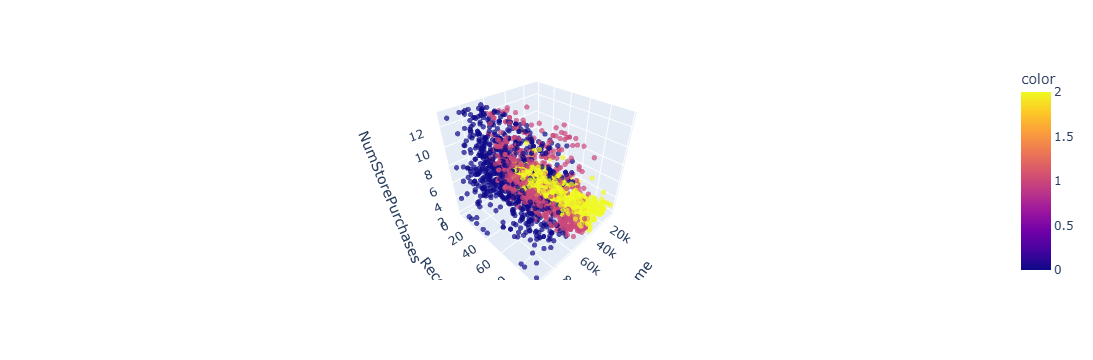

In [59]:

fig = px.scatter_3d(
    customers_df, 
    x="Income", 
    y="Recency", 
    z="NumStorePurchases",
    color=labels, 
    opacity=0.7,
)
fig.update_traces(marker=dict(size=3))  

fig.show()

In [13]:
import plotly.express as px
def plot_3d(customers_df, labels):
    customers_df["TotalSpent"] = customers_df[["MntWines", "MntFruits", "MntMeatProducts", 
                           "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)

    customers_df["TotalPurchases"] = customers_df[["NumDealsPurchases", "NumWebPurchases", 
                               "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1)
    
    fig = px.scatter_3d(
        customers_df, 
        x="Income", 
        y="TotalSpent", 
        z="TotalPurchases",
        color=labels, 
        opacity=0.7,
    )
    fig.update_traces(marker=dict(size=3))  
    
    fig.show()

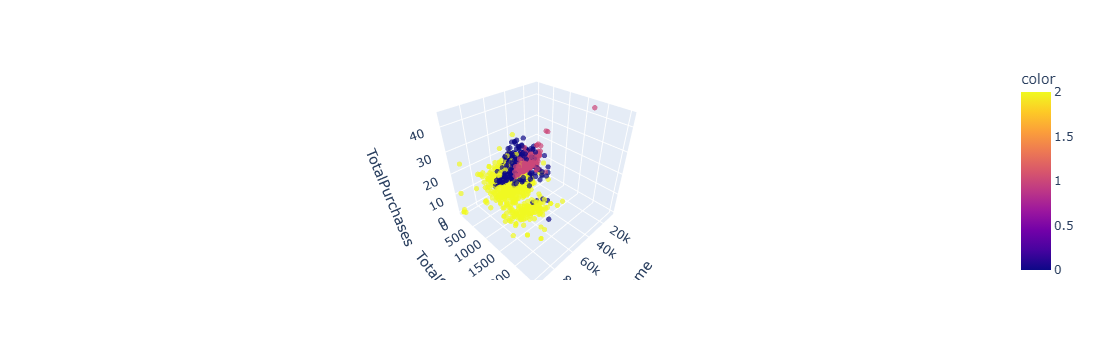

In [17]:
plot_3d(customers_df, labels)

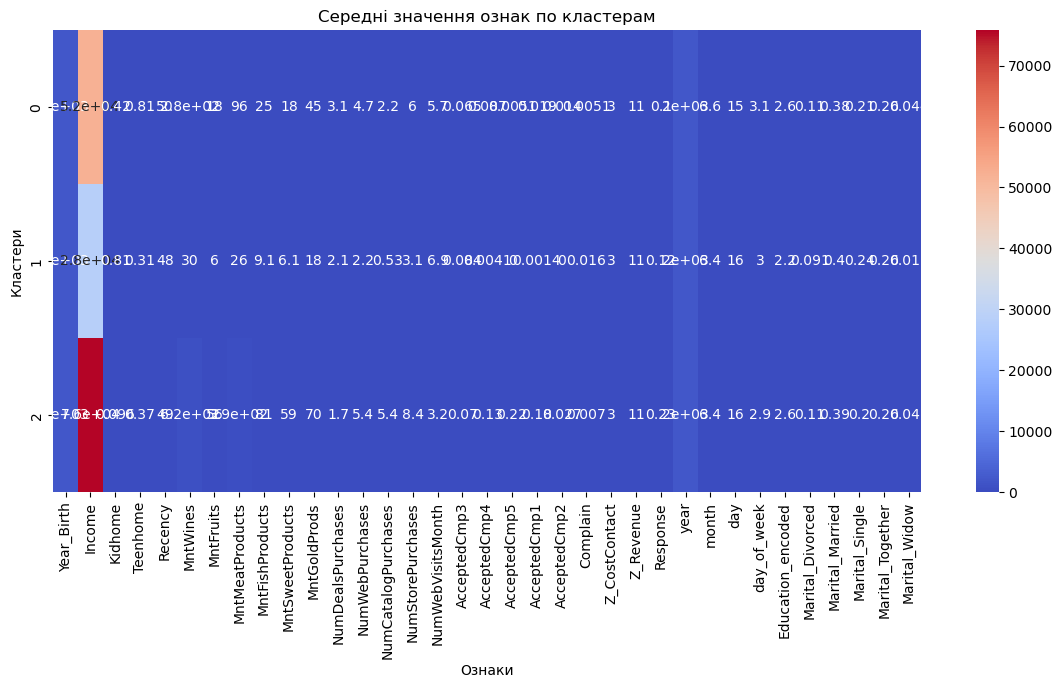

In [33]:
heatmap_df = pd.DataFrame(X, columns=X.columns).copy()
heatmap_df['3_clust_kmeans'] = labels


import seaborn as sns
import matplotlib.pyplot as plt

cluster_profiles = heatmap_df.groupby("3_clust_kmeans").mean()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, annot=True, cmap="coolwarm", cbar=True)

plt.title("Середні значення ознак по кластерам")
plt.ylabel("Кластери")
plt.xlabel("Ознаки")
plt.show()

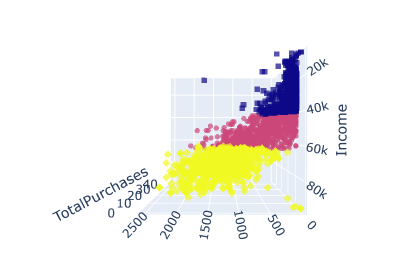
Виглядає, що модель розділила дані по кластерах за Income. Але все рівно, можна побачити, що синій кластер це здебільшого люди які здійснили мало покупок та витратили небагато грошей. А от жовтий і червоний кластери досить змішані з цього погляду, вони чітко розділені по доходу, але для нас як для бізнесу це не так важливо як продажі
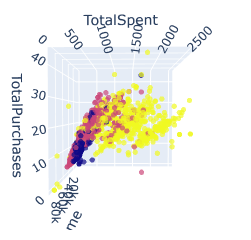

**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

Silhouette Coefficient for the data Dataset Clusters: 0.11


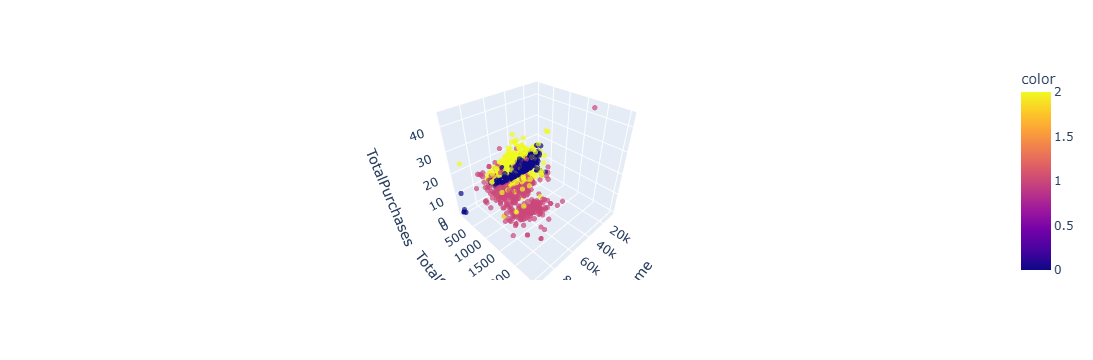

In [29]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'Income', 'Year_Birth', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Education_encoded'
]


X_scale = X.copy()
X_scale = StandardScaler().fit_transform(X_scale)

kmeanssc = KMeans(n_clusters=3, n_init='auto')
kmeanssc.fit(X_scale)
labels_scale = kmeanssc.predict(X_scale)
centroids = kmeanssc.cluster_centers_
s = metrics.silhouette_score(X_scale, labels_scale, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')
plot_3d(customers_df, labels_scale)

Після масштабування даних метрика силуету жахлива, але дані розділилися на три групи за трьома ознаками в об'ємі, а не тільки по Income 

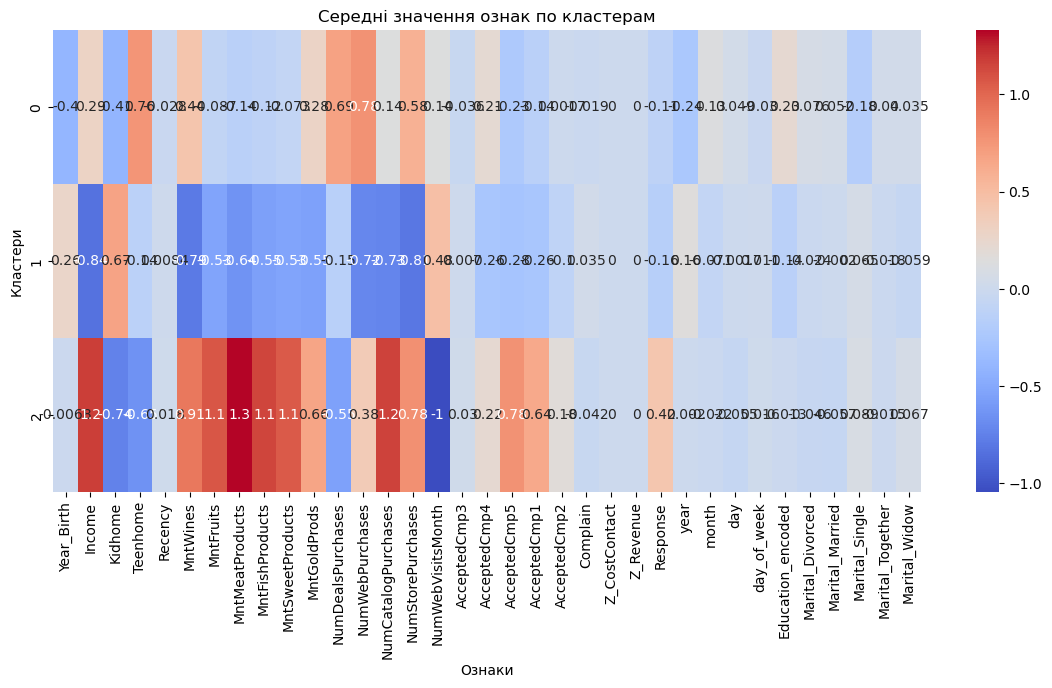

In [27]:
result_scaled = pd.DataFrame(X_scale, columns=X.columns).copy()
result_scaled['3_clust_kmeans'] = labels_scale


import seaborn as sns
import matplotlib.pyplot as plt

cluster_profiles = result_scaled.groupby("3_clust_kmeans").mean()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, annot=True, cmap="coolwarm", cbar=True)

plt.title("Середні значення ознак по кластерам")
plt.ylabel("Кластери")
plt.xlabel("Ознаки")
plt.show()

З теплової карти можемо добре побачити, що модель розділила дані на три кластера по багатьом ознакам, це більш якісний результат. Хоча показник силуету впав, тому що відстані між точками після масштабування стали меньші

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [82]:
cols_to_clip = [
    'Income', 'Year_Birth', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth'
]


q_low, q_high = X['Income'].quantile([0.01, 0.95])
X['Income'] = X['Income'].clip(lower=q_low, upper=q_high)

C:\Users\hp\AppData\Local\Temp\ipykernel_3140\1551606369.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



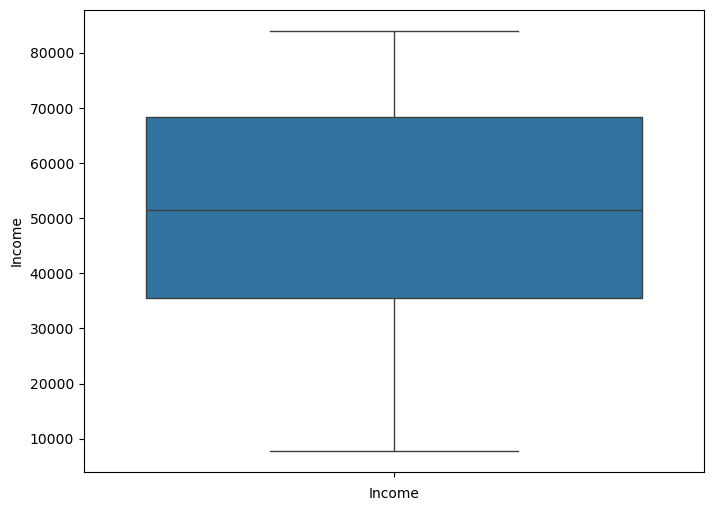

In [59]:
plt.figure(figsize=(8,6))
sns.boxplot(y=X["Income"])
plt.xlabel("Income")
plt.show()

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

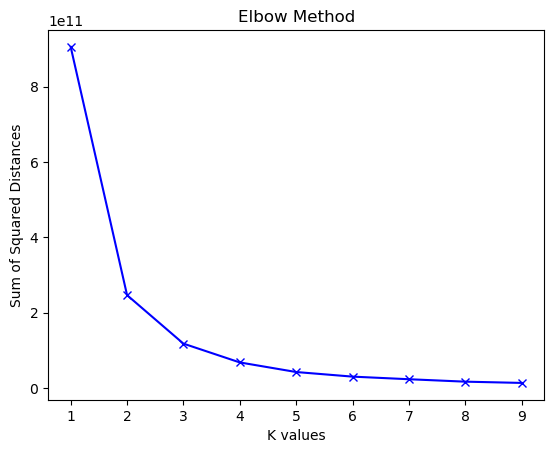

In [61]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

Silhouette Coefficient for the data Dataset Clusters: 0.56


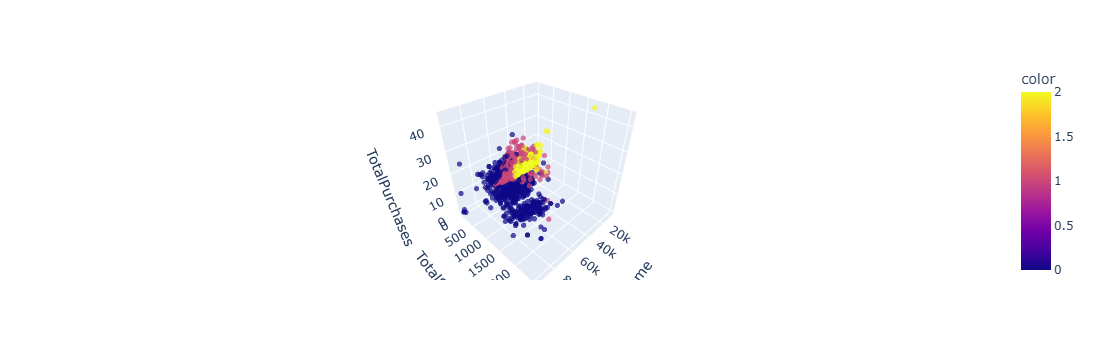

In [63]:
kmeans2 = KMeans(n_clusters=3, n_init='auto')
kmeans2.fit(X)
labels2 = kmeans2.predict(X)
centroids = kmeans2.cluster_centers_
s = metrics.silhouette_score(X, labels2, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')
plot_3d(customers_df, labels2)

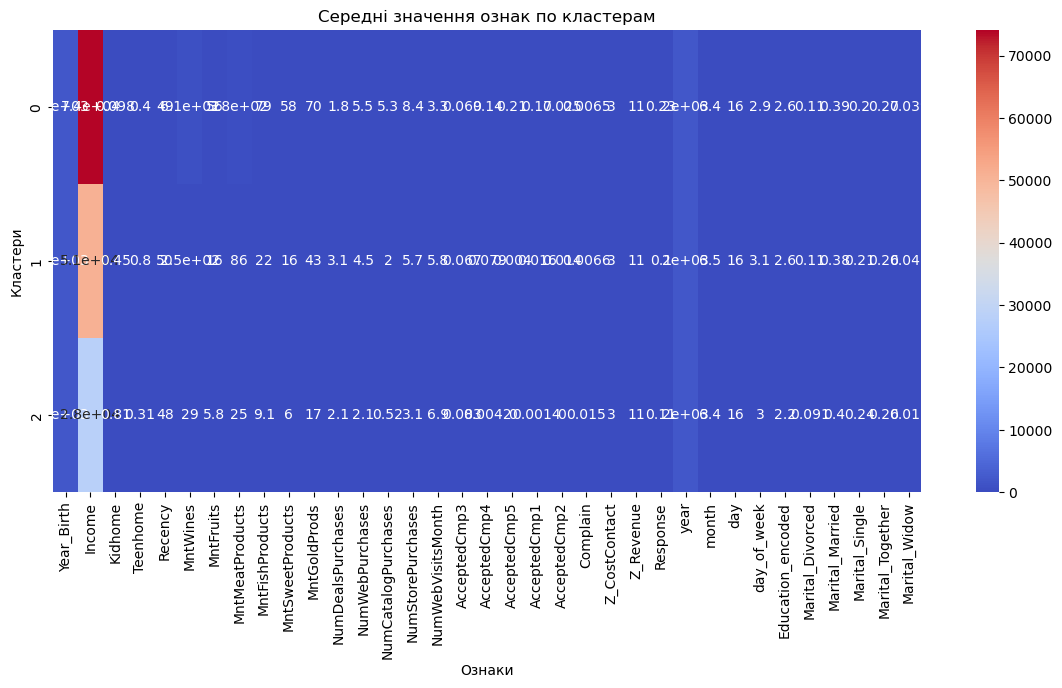

In [65]:
heatmap_df = pd.DataFrame(X, columns=X.columns).copy()
heatmap_df['3_clust_kmeans_w'] = labels2

cluster_profiles = heatmap_df.groupby("3_clust_kmeans_w").mean()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, annot=True, cmap="coolwarm", cbar=True)

plt.title("Середні значення ознак по кластерам")
plt.ylabel("Кластери")
plt.xlabel("Ознаки")
plt.show()

Silhouette Coefficient for the data Dataset Clusters: 0.56


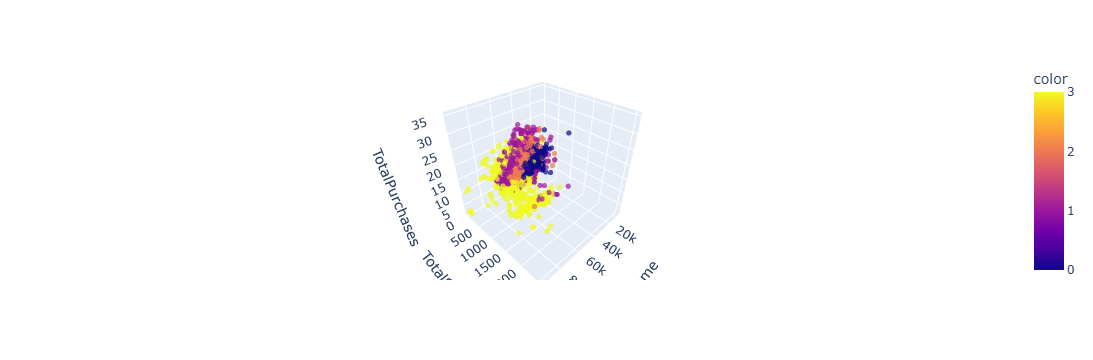

In [65]:
kmeans4 = KMeans(n_clusters=4, n_init='auto')
kmeans4.fit(X)
labels4 = kmeans4.predict(X)
centroids = kmeans4.cluster_centers_
s = metrics.silhouette_score(X, labels4, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')
plot_3d(customers_df, labels4)

Оптимальною виявилась таж кількість кластерів з якою ми працювали і раніше. І на немасштабованих даних, кластери розділяються так саме тільки за Income

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

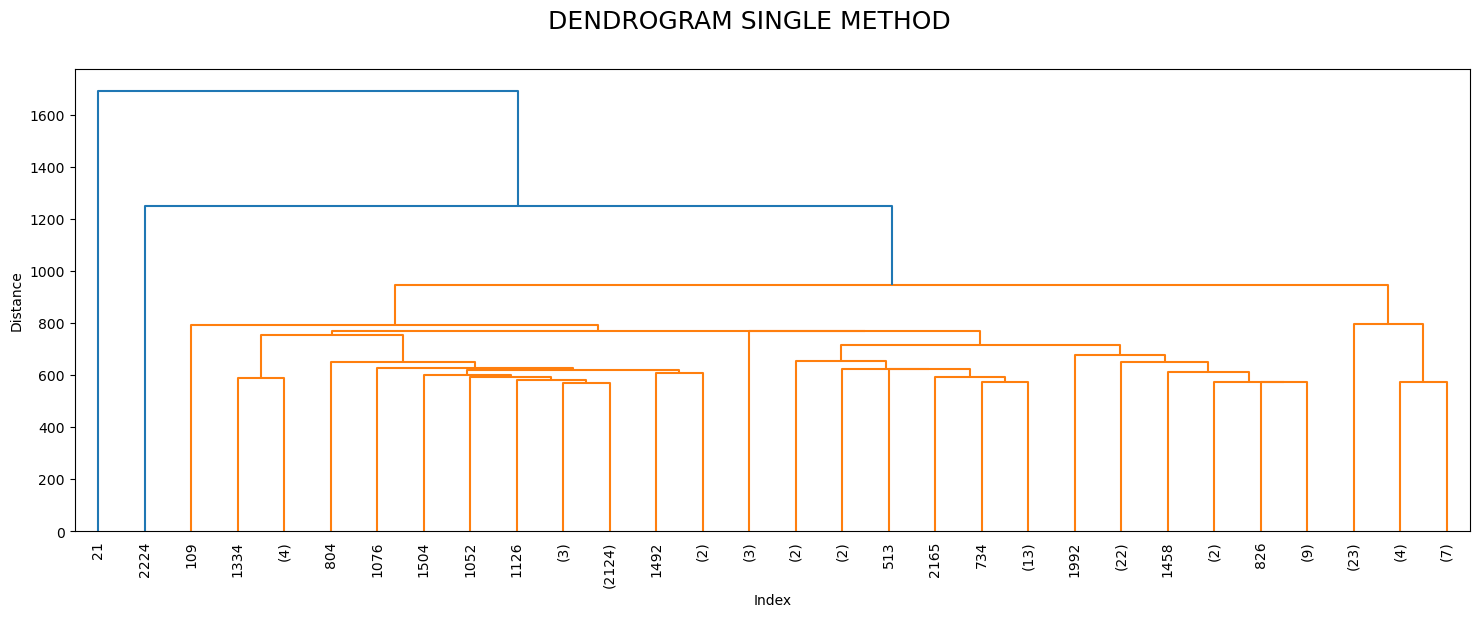

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns
import matplotlib.pyplot as plt

dist_sin = linkage(X, method="single")
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD",fontsize=18)
plt.show()

In [ ]:
X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

In [84]:
plot_3d(customers_df, X['2_clust'])

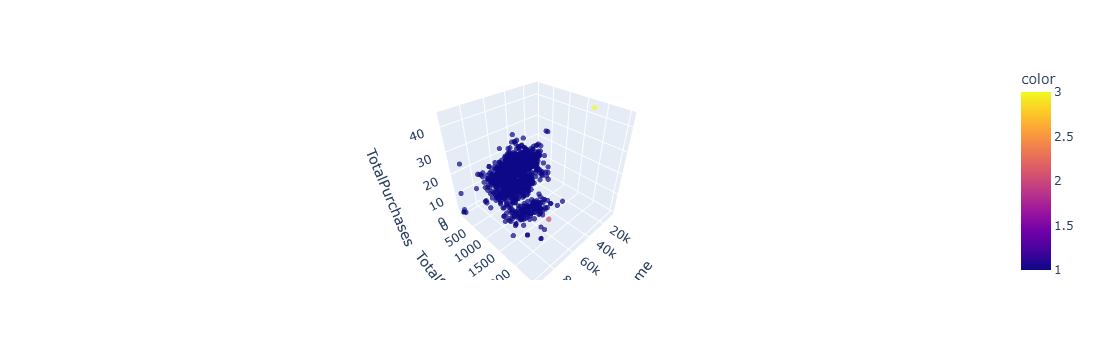

In [25]:
plot_3d(customers_df, X['3_clust'])

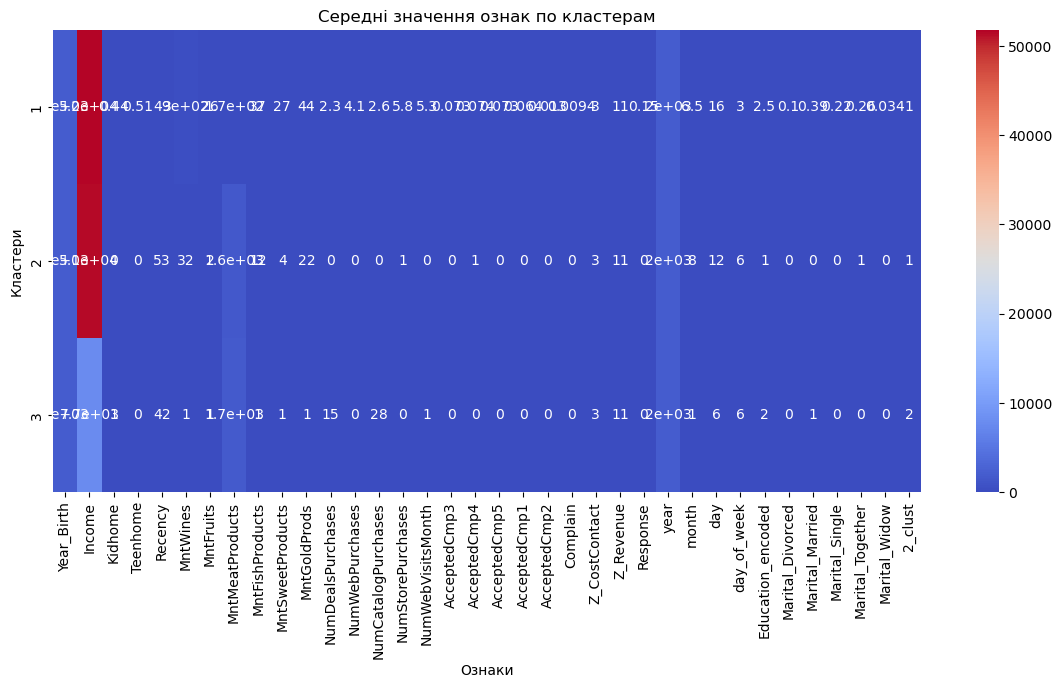

In [27]:
plt.figure(figsize=(14, 6))
sns.heatmap(X.groupby("3_clust").mean(), annot=True, cmap="coolwarm", cbar=True)

plt.title("Середні значення ознак по кластерам")
plt.ylabel("Кластери")
plt.xlabel("Ознаки")
plt.show()

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, X['3_clust'], metric='euclidean')
print(f"Silhouette Coefficient: {score:.2f}")

Silhouette Coefficient: -0.40


Ці методи не дуже добре впорались на цих даних, можливо тому що дані досить рівномірно розташовані. З теплової мапи видно, що дані розділились тільки за Income і то досить невдало. На дендрограмі можна побачити, що два класа з трьох містять тільки один елемент. Можливо, якщо забрати ці дві точки які віддалені від інших, кластеризвція вийшла би більш вдалою

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

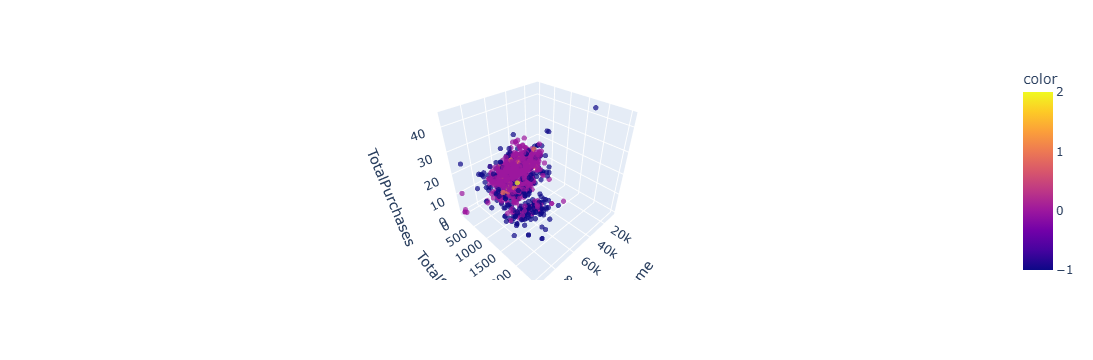

In [61]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=5, min_samples=10)
dbscan.fit(X_scale)
labels_db = dbscan.labels_
plot_3d(customers_df, labels_db)

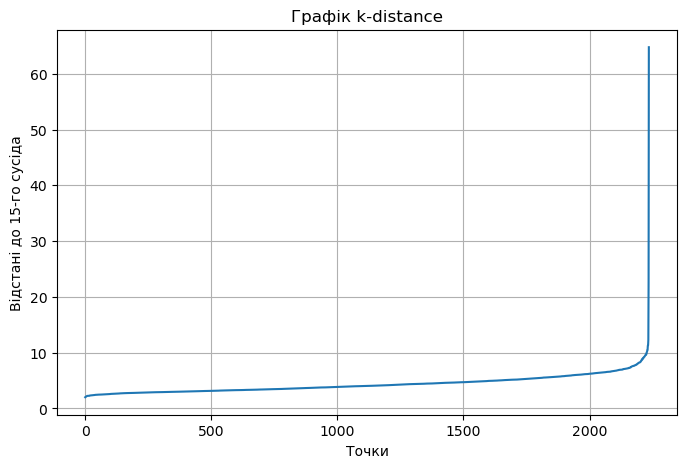

In [55]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 15
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scale)

distances, indices = nn.kneighbors(X_scale)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("Графік k-distance")
plt.xlabel("Точки")
plt.ylabel(f"Відстані до {k}-го сусіда")
plt.grid(True)
plt.show()

In [59]:
from sklearn.cluster import DBSCAN
import pandas as pd

results = []
eps_list = np.linspace(0.1, 5.0, 50)  # подбирай диапазон по оси графика k-distance
min_samples_list = [3,5,7,10]

for min_s in min_samples_list:
    for eps in eps_list:
        db = DBSCAN(eps=eps, min_samples=min_s).fit(X_scale)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = (labels == -1).mean()
        results.append((min_s, eps, n_clusters, noise_ratio))

res_df = pd.DataFrame(results, columns=['min_samples','eps','n_clusters','noise_ratio'])
display(res_df)

,min_samples,eps,n_clusters,noise_ratio
0,3,0.1,6,0.991950
1,3,0.2,6,0.991950
2,3,0.3,6,0.991950
3,3,0.4,6,0.991950
4,3,0.5,6,0.991950
...,...,...,...,...
195,10,4.6,2,0.209302
196,10,4.7,2,0.199911
197,10,4.8,3,0.179338
198,10,4.9,3,0.167263


In [65]:
pip install hdbscan

   ---------------------------------------- 0.0/726.2 kB ? eta -:--:--
   ---------------------------- ----------- 524.3/726.2 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 726.2/726.2 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [88]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
labels_hd = clusterer.fit_predict(X_scale)
plot_3d(customers_df, labels_hd)

In [69]:
score = silhouette_score(X, labels_db, metric='euclidean')
print(f"Silhouette Coefficient: {score:.2f}")

Silhouette Coefficient: -0.30


На наших даних немає видимих розділеннь на кластери з відстанями між ними, тому DBSCAN також не дуже добре себе показав.
З тих методів що я спробувала найкраще себе показав KMeans на масштабованих даних 